In [ ]:
# ===========================
# Hybrid Rug-Pull Detector – Final 3-Layer Version (FIXED)
# CodeBERT + Simulated Forta + CRPWarner + LightGBM
# ===========================

!apt-get update -qq && apt-get install -y -qq unrar > /dev/null
!pip install -q torch transformers scikit-learn pandas openpyxl rarfile joblib tqdm matplotlib seaborn lightgbm

import os
import zipfile
import shutil
import warnings
import math
import re
from google.colab import files
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import rarfile
import joblib
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import torch
from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings("ignore")

PCA_COMPONENTS = 128
RESULTS_DIR = '/content/results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# 1) UPLOAD FILES
print("لطفاً فایل‌های زیر را آپلود کنید:\n1) dataset.xlsx\n2) SOURCE CODE.zip/rar\n3) crpwarner.xlsx")
uploaded = files.upload()

excel_file = [f for f in uploaded if 'dataset' in f.lower()][0]
archive_file = [f for f in uploaded if f.lower().endswith(('.zip','.rar'))][0]
crp_file = [f for f in uploaded if 'crp' in f.lower()][0]

# Load and standardize key column as STRING
df = pd.read_excel(excel_file)
crp = pd.read_excel(crp_file)

# 🔑 تبدیل ستون کلیدی به رشته در همه جا
df["Smart Contract Offline"] = df["Smart Contract Offline"].astype(str)
crp["Smart Contract Offline"] = crp["Smart Contract Offline"].astype(str)

print(f"Dataset rows: {len(df)}")
print(f"CRPWarner rows: {len(crp)}")

# 2) Extract contracts
CONTRACTS_DIR = "/content/contracts"
if os.path.exists(CONTRACTS_DIR):
    shutil.rmtree(CONTRACTS_DIR)
os.makedirs(CONTRACTS_DIR, exist_ok=True)

if archive_file.endswith(".zip"):
    with zipfile.ZipFile(archive_file) as z:
        z.extractall(CONTRACTS_DIR)
else:
    with rarfile.RarFile(archive_file) as rf:
        rf.extractall(CONTRACTS_DIR)

# 3) Simulated Forta Rules
rules = [
    (r'owner\b|onlyOwner\b|Ownable', 1.8, 'owner'),
    (r'withdraw\b|drain\b|emergencyWithdraw\b', 2.5, 'withdraw'),
    (r'\.call\(|delegatecall\(', 2.2, 'low_level'),
    (r'assembly\s*{', 2.0, 'assembly'),
    (r'renounceOwnership', 2.0, 'renounce'),
    (r'mint\s*\(', 1.6, 'mint'),
    (r'setFee|setTax|feeTo|tax', 1.8, 'fee_mod'),
    (r'blacklist|excludeFromFee|isExcluded', 2.8, 'blacklist'),
]

def simulate_forta(code):
    feats = {'sim_forta_raw': 0.0, 'sim_forta_risk': 0.0}
    total = 0.0
    for pat, wt, name in rules:
        cnt = len(re.findall(pat, code, flags=re.IGNORECASE))
        feats[f'count_{name}'] = cnt
        feats[f'score_{name}'] = cnt * wt
        total += cnt * wt
    feats['sim_forta_raw'] = total
    feats['sim_forta_risk'] = math.tanh(total / 8.0)
    return feats

# 4) Map smart contracts (keys as LOWERCASE STRINGS)
contract_files = {}
for root, dirs, files_ in os.walk(CONTRACTS_DIR):
    for f in files_:
        contract_files[os.path.splitext(f)[0].lower()] = os.path.join(root, f)

# 5) Apply Forta simulation
forta_rows = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Simulated Forta"):
    name_key = str(row["Smart Contract Offline"])
    name = name_key.lower()
    path = contract_files.get(name)
    code = open(path, 'r', errors='ignore').read() if path else ""
    feats = simulate_forta(code) if code else {k: 0 for k in simulate_forta("").keys()}
    feats["Smart Contract Offline"] = name_key
    feats["Label"] = row["Label"]
    forta_rows.append(feats)

forta_df = pd.DataFrame(forta_rows)
forta_df["Smart Contract Offline"] = forta_df["Smart Contract Offline"].astype(str)

# 6) CodeBERT Embedding
print("Loading CodeBERT...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
model = AutoModel.from_pretrained("microsoft/codebert-base").to(device)
model.eval()

def embed_code(code):
    if not code.strip():
        return np.zeros(768, dtype=np.float32)
    tokens = tokenizer(code, return_tensors="pt", truncation=True, max_length=512, padding="max_length")
    tokens = {k: v.to(device) for k, v in tokens.items()}
    with torch.no_grad():
        out = model(**tokens)
    return out.last_hidden_state.mean(dim=1).cpu().numpy().flatten()

emb_rows = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="CodeBERT Embedding"):
    name_key = str(row["Smart Contract Offline"])
    name = name_key.lower()
    path = contract_files.get(name)
    code = open(path, 'r', errors='ignore').read() if path else ""
    vec = embed_code(code)
    emb_rows.append({
        "Smart Contract Offline": name_key,
        **{f"emb_{i}": float(vec[i]) for i in range(768)}
    })

emb_df = pd.DataFrame(emb_rows)
emb_df["Smart Contract Offline"] = emb_df["Smart Contract Offline"].astype(str)

# 7) PCA
print(f"Applying PCA to {PCA_COMPONENTS} dims...")
emb_cols = [c for c in emb_df.columns if c.startswith("emb_")]
emb_matrix = emb_df[emb_cols].values.astype(np.float32)
pca = PCA(n_components=PCA_COMPONENTS, random_state=42)
reduced = pca.fit_transform(emb_matrix)

pca_df = pd.DataFrame(reduced, columns=[f"pca_{i}" for i in range(PCA_COMPONENTS)])
pca_df["Smart Contract Offline"] = emb_df["Smart Contract Offline"].astype(str)

# 8) ADD LAYER 3 → CRPWarner
crp = crp[["Smart Contract Offline", "HiddenMint", "LeakingToken", "LimitingSell"]]

# 9) Final Merge
merged = (
    forta_df
    .merge(pca_df, on="Smart Contract Offline", how="inner")
    .merge(crp, on="Smart Contract Offline", how="left")
)

merged[["HiddenMint", "LeakingToken", "LimitingSell"]] = merged[["HiddenMint", "LeakingToken", "LimitingSell"]].fillna(0)

merged["y"] = merged["Label"].map({"normal": 0, "scam": 1, 0: 0, 1: 1})

feature_cols = [c for c in merged.columns if c not in ["Smart Contract Offline", "Label", "y"]]
X = merged[feature_cols].fillna(0).astype(np.float32).values
y = merged["y"].astype(int).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# 10) LightGBM
print("Training LightGBM...")
pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

params = {
    "objective": "binary",
    "metric": "binary_logloss,auc",
    "learning_rate": 0.03,
    "num_leaves": 128,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l1": 0.1,
    "lambda_l2": 0.2,
    "scale_pos_weight": pos_weight,
    "verbosity": -1,
    "seed": 42,
    "device": "gpu" if torch.cuda.is_available() else "cpu"
}

dtrain = lgb.Dataset(X_train, label=y_train)
dvalid = lgb.Dataset(X_test, label=y_test, reference=dtrain)

clf = lgb.train(
    params,
    dtrain,
    num_boost_round=5000,
    valid_sets=[dtrain, dvalid],
    valid_names=["train", "valid"],
    callbacks=[
        lgb.early_stopping(150, verbose=True),
        lgb.log_evaluation(100)
    ]
)

# 11) Results
yp = clf.predict(X_test)
ypred = (yp >= 0.5).astype(int)

print(classification_report(y_test, ypred))
print("ROC-AUC:", roc_auc_score(y_test, yp))

joblib.dump(clf, "/content/results/model.joblib")
joblib.dump(scaler, "/content/results/scaler.joblib")
merged.to_csv("/content/results/final_features.csv", index=False)

print("✅ DONE.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
لطفاً فایل‌های زیر را آپلود کنید:
1) dataset.xlsx
2) SOURCE CODE.zip/rar
3) crpwarner.xlsx


Saving crpwarner.xlsx to crpwarner (4).xlsx
Saving dataset.xlsx to dataset (4).xlsx
Saving SOURCE CODE.rar to SOURCE CODE (4).rar
Dataset rows: 1000
CRPWarner rows: 1000


Simulated Forta:   0%|          | 0/1000 [00:00<?, ?it/s]

Loading CodeBERT...


CodeBERT Embedding:   0%|          | 0/1000 [00:00<?, ?it/s]

Applying PCA to 128 dims...
Training LightGBM...
Training until validation scores don't improve for 150 rounds
[100]	train's binary_logloss: 0.214849	train's auc: 0.997971	valid's binary_logloss: 0.44298	valid's auc: 0.875982
[200]	train's binary_logloss: 0.0963438	train's auc: 0.999874	valid's binary_logloss: 0.434316	valid's auc: 0.875672
Early stopping, best iteration is:
[60]	train's binary_logloss: 0.317647	train's auc: 0.990882	valid's binary_logloss: 0.466685	valid's auc: 0.881253
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        82
           1       0.87      0.87      0.87       118

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200

ROC-AUC: 0.8812525837122778
✅ DONE.


In [ ]:
import pandas as pd
df = pd.read_excel("dataset.xlsx")
print("تمام ستون‌های dataset.xlsx:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. '{col}'")
print("\nآیا ستونی شبیه این‌ها وجود دارد؟")
print("- is_scam, label, target")
print("- honeypot, proxy, verified")
print("- has_mint, has_blacklist, is_erc20")
print("- any column that leaks the label!")

تمام ستون‌های dataset.xlsx:
1. 'title'
2. 'Max Price Q1'
3. 'Max Price Q2'
4. 'Max Price Q3'
5. 'Max Price Q4'
6. 'Blockchain Type'
7. 'Transaction Count'
8. 'Token Concentration Ratio'
9. 'Holder Variance Total'
10. 'Holder Variance Top 1%'
11. 'Initial Token Supply'
12. 'Token Type'
13. 'Initial Deposit Count'
14. 'Consensus Mechanism'
15. 'Smart Contract Online'
16. 'Smart Contract Offline'
17. 'Website Presence'
18. 'X Presence (Twitter)'
19. 'Label'
20. 'Project Start Time'
21. 'Project End Time'
22. 'Google Search Hits (Project Title, Total)'
23. 'Google Search Hits (Project Title, First Half)'
24. 'Google Search Hits (Official Domain, Total)'
25. 'Google Search Hits (Official Domain, First Half)'
26. 'Tweet Volume (Total)'
27. 'Tweet Volume (First Half)'
28. 'نصف بازه پروژه'

آیا ستونی شبیه این‌ها وجود دارد؟
- is_scam, label, target
- honeypot, proxy, verified
- has_mint, has_blacklist, is_erc20
- any column that leaks the label!


In [ ]:
# ===========================
# Best Final Version
# Soft Cascade Forta + CodeBERT + LightGBM
# ===========================

!apt-get update -qq && apt-get install -y -qq unrar > /dev/null
!pip install -q torch transformers scikit-learn pandas openpyxl rarfile tqdm lightgbm

import os, zipfile, shutil, re, warnings
from google.colab import files
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import rarfile
import torch
import lightgbm as lgb
from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

warnings.filterwarnings("ignore")

PCA_COMPONENTS = 128
SEED = 42

# ===========================
# 1) Upload
# ===========================
print("آپلود کنید:\n1) dataset.xlsx\n2) SOURCE_CODE.zip یا rar")
uploaded = files.upload()

excel_file = [f for f in uploaded if 'dataset' in f.lower()][0]
archive_file = [f for f in uploaded if f.lower().endswith(('.zip','.rar'))][0]

df = pd.read_excel(excel_file)
df["Smart Contract Offline"] = df["Smart Contract Offline"].astype(str)
df["y"] = df["Label"].map({"normal": 0, "scam": 1, 0: 0, 1: 1}).astype(int)

# ===========================
# 2) Extract contracts
# ===========================
CONTRACTS_DIR = "/content/contracts"
shutil.rmtree(CONTRACTS_DIR, ignore_errors=True)
os.makedirs(CONTRACTS_DIR, exist_ok=True)

if archive_file.endswith(".zip"):
    with zipfile.ZipFile(archive_file) as z:
        z.extractall(CONTRACTS_DIR)
else:
    with rarfile.RarFile(archive_file) as rf:
        rf.extractall(CONTRACTS_DIR)

contract_files = {}
for root, _, files_ in os.walk(CONTRACTS_DIR):
    for f in files_:
        contract_files[os.path.splitext(f)[0].lower()] = os.path.join(root, f)

# ===========================
# 3) Forta score (ONLY for bias, not decision)
# ===========================
rules = [
    (r'onlyOwner|owner\b|Ownable', 1.5),
    (r'mint\s*\(', 2.5),
    (r'blacklist|isBlacklisted|excludeFromFee', 3.0),
    (r'setFee|setTax|taxFee', 2.0),
    (r'withdraw|drain|emergencyWithdraw', 2.5),
    (r'delegatecall|\.call\(', 2.0),
    (r'assembly\s*{', 1.5),
]

def forta_score(code):
    s = 0.0
    for pat, w in rules:
        s += len(re.findall(pat, code, flags=re.IGNORECASE)) * w
    return s

forta_scores = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Forta"):
    key = row["Smart Contract Offline"].lower()
    path = contract_files.get(key)
    code = open(path, "r", errors="ignore").read() if path else ""
    forta_scores.append(forta_score(code))

forta_scores = np.array(forta_scores)

# extreme-only bias (VERY IMPORTANT)
hi_thr = np.percentile(forta_scores, 90)
lo_thr = np.percentile(forta_scores, 10)

HIGH = forta_scores >= hi_thr
LOW  = forta_scores <= lo_thr

print("High-risk (override=1):", HIGH.sum())
print("Low-risk  (override=0):", LOW.sum())

# ===========================
# 4) CodeBERT
# ===========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
model_bert = AutoModel.from_pretrained("microsoft/codebert-base").to(device)
model_bert.eval()

def embed(code):
    if not code.strip():
        return np.zeros(768, dtype=np.float32)
    t = tokenizer(code, return_tensors="pt", truncation=True,
                  max_length=512, padding="max_length")
    t = {k: v.to(device) for k, v in t.items()}
    with torch.no_grad():
        out = model_bert(**t)
    return out.last_hidden_state.mean(1).cpu().numpy().flatten()

embs = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="CodeBERT"):
    key = row["Smart Contract Offline"].lower()
    path = contract_files.get(key)
    code = open(path, "r", errors="ignore").read() if path else ""
    embs.append(embed(code))

embs = np.vstack(embs)

# ===========================
# 5) PCA
# ===========================
pca = PCA(n_components=PCA_COMPONENTS, random_state=SEED)
X = pca.fit_transform(embs)
y = df["y"].values

# ===========================
# 6) Train/Test
# ===========================
Xtr, Xte, ytr, yte, idx_tr, idx_te = train_test_split(
    X, y, np.arange(len(y)),
    test_size=0.2, stratify=y, random_state=SEED
)

# ===========================
# 7) LightGBM (stable setup)
# ===========================
params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.03,
    "num_leaves": 128,
    "min_data_in_leaf": 20,
    "feature_fraction": 0.85,
    "bagging_fraction": 0.85,
    "bagging_freq": 1,
    "verbosity": -1,
    "seed": SEED
}

model = lgb.train(
    params,
    lgb.Dataset(Xtr, label=ytr),
    valid_sets=[lgb.Dataset(Xte, label=yte)],
    num_boost_round=3000,
    callbacks=[lgb.early_stopping(150)]
)

# ===========================
# 8) Soft Cascade Fusion
# ===========================
yp = model.predict(X)

y_final = (yp >= 0.5).astype(int)
y_final[HIGH] = 1
y_final[LOW]  = 0

# ===========================
# 9) Evaluation
# ===========================
print(classification_report(y, y_final))
print("Accuracy:", round((y == y_final).mean(), 4))
print("ROC-AUC:", round(roc_auc_score(y, yp), 4))

print("✅ DONE")


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
آپلود کنید:
1) dataset.xlsx
2) SOURCE_CODE.zip یا rar


Saving dataset.xlsx to dataset (6).xlsx
Saving SOURCE CODE.rar to SOURCE CODE (6).rar


Forta:   0%|          | 0/1000 [00:00<?, ?it/s]

High-risk (override=1): 100
Low-risk  (override=0): 110


CodeBERT:   0%|          | 0/1000 [00:00<?, ?it/s]

Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[185]	valid_0's auc: 0.871331
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       408
           1       0.89      0.88      0.88       592

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.87      0.86      0.87      1000

Accuracy: 0.865
ROC-AUC: 0.9897
✅ DONE


In [ ]:
# ===========================
# FINAL THREE-LAYER ARCHITECTURE
# Forta (Sun et al. 2024) + CodeBERT + CRP-WARNER (Static Analyzer)
# ===========================

!apt-get update -qq && apt-get install -y -qq unrar > /dev/null
!pip install -q torch transformers scikit-learn pandas openpyxl rarfile tqdm lightgbm

import os, zipfile, shutil, re, warnings
from google.colab import files
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import rarfile
import torch
import lightgbm as lgb
from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

warnings.filterwarnings("ignore")

PCA_COMPONENTS = 128
SEED = 42

# ===========================
# 1) Upload: dataset.xlsx, crpwarner.xlsx, SOURCE_CODE
# ===========================
print("آپلود کنید:\n1) dataset.xlsx\n2) crpwarner.xlsx\n3) SOURCE_CODE.zip یا rar")
uploaded = files.upload()

excel_file = [f for f in uploaded if 'dataset' in f.lower()][0]
crp_file = [f for f in uploaded if 'crp' in f.lower()][0]
archive_file = [f for f in uploaded if f.lower().endswith(('.zip', '.rar'))][0]

df = pd.read_excel(excel_file)
df["Smart Contract Offline"] = df["Smart Contract Offline"].astype(str)
df["y"] = df["Label"].map({"normal": 0, "scam": 1, 0: 0, 1: 1}).astype(int)

df_crp = pd.read_excel(crp_file)
df_crp["Smart Contract Offline"] = df_crp["Smart Contract Offline"].astype(str)

# تضمین همسانی ردیف‌ها بر اساس "Smart Contract Offline"
df = df.merge(df_crp[["Smart Contract Offline", "HiddenMint", "LeakingToken", "LimitingSell"]],
              on="Smart Contract Offline", how="left")

# جایگزینی مقادیر NaN با 0 (در صورت عدم وجود برای برخی قراردادها)
df[["HiddenMint", "LeakingToken", "LimitingSell"]] = df[["HiddenMint", "LeakingToken", "LimitingSell"]].fillna(0).astype(int)

# ===========================
# 2) Extract contracts
# ===========================
CONTRACTS_DIR = "/content/contracts"
shutil.rmtree(CONTRACTS_DIR, ignore_errors=True)
os.makedirs(CONTRACTS_DIR, exist_ok=True)

if archive_file.endswith(".zip"):
    with zipfile.ZipFile(archive_file) as z:
        z.extractall(CONTRACTS_DIR)
else:
    with rarfile.RarFile(archive_file) as rf:
        rf.extractall(CONTRACTS_DIR)

contract_files = {}
for root, _, files_ in os.walk(CONTRACTS_DIR):
    for f in files_:
        contract_files[os.path.splitext(f)[0].lower()] = os.path.join(root, f)

# ===========================
# 3) Safe regex helper
# ===========================
def in_code_context(code, pattern):
    lines = code.split('\n')
    for line in lines:
        if '//' in line:
            line = line.split('//')[0]
        if line.strip() and re.search(pattern, line, re.IGNORECASE):
            return True
    return False

# ===========================
# 4) Forta Score — Sun et al. (2024) aligned
# ===========================
def forta_score(code):
    if not isinstance(code, str) or not code.strip():
        return 0.0
    score = 0.0
    # Token Generation
    if in_code_context(code, r'\bmint\s*\(|_mint|mintFrom'): score += 2.5
    # Destroy Token
    if in_code_context(code, r'\b_burn|burnFrom|destroyTokens'): score += 2.0
    # Blacklist / Freeze
    if in_code_context(code, r'\bblacklist|isBlacklisted'): score += 3.0
    if in_code_context(code, r'\bfreezeAccount|isFrozen'): score += 2.5
    if in_code_context(code, r'\bonlyOwner|owner\b|Ownable'): score += 2.0
    # Fee
    if in_code_context(code, r'\bsetFee|setTax|taxFee|_tax'): score += 2.5
    # LP Drain
    if in_code_context(code, r'\b(withdraw|drain|emergencyWithdraw|drainAll|sweep)'): score += 3.0
    # Ownership & Proxy
    if in_code_context(code, r'\btransferOwnership|_owner\s*='): score += 2.0
    if in_code_context(code, r'\bupgradeTo|_implementation'): score += 2.5
    # External Call
    if in_code_context(code, r'\.call\(|delegatecall'): score += 2.5
    # Vulnerability
    if in_code_context(code, r'\bassembly\s*\{'): score += 1.5
    return score

# ===========================
# 5) Apply Forta
# ===========================
forta_scores = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Forta (Taxonomy-Based)"):
    key = row["Smart Contract Offline"].lower()
    path = contract_files.get(key)
    code = open(path, "r", errors="ignore").read() if path else ""
    forta_scores.append(forta_score(code))

forta_scores = np.array(forta_scores)

# Override masks
hi_thr = np.percentile(forta_scores, 90)
lo_thr = np.percentile(forta_scores, 10)
HIGH = forta_scores >= hi_thr
LOW  = forta_scores <= lo_thr

print("High-risk (override=1):", HIGH.sum())
print("Low-risk  (override=0):", LOW.sum())

# ===========================
# 6) CodeBERT Embeddings
# ===========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
model_bert = AutoModel.from_pretrained("microsoft/codebert-base").to(device)
model_bert.eval()

def embed(code):
    if not code or not code.strip():
        return np.zeros(768, dtype=np.float32)
    inputs = tokenizer(code, return_tensors="pt", truncation=True, max_length=512, padding="max_length")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        out = model_bert(**inputs)
    return out.last_hidden_state.mean(dim=1).cpu().numpy().flatten()

embs = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="CodeBERT"):
    key = row["Smart Contract Offline"].lower()
    path = contract_files.get(key)
    code = open(path, "r", errors="ignore").read() if path else ""
    embs.append(embed(code))

embs = np.vstack(embs)

# ===========================
# 7) Feature Fusion: PCA + Forta + CRP-WARNER
# ===========================
pca = PCA(n_components=PCA_COMPONENTS, random_state=SEED)
X_pca = pca.fit_transform(embs)

# Normalize Forta
forta_norm = (forta_scores - forta_scores.mean()) / (forta_scores.std() + 1e-8)

# CRP-WARNER features (3 binary features)
crp_features = df[["HiddenMint", "LeakingToken", "LimitingSell"]].values

# Concatenate all: [PCA(128) + Forta(1) + CRP(3)] → 132 features
X = np.hstack([X_pca, forta_norm.reshape(-1, 1), crp_features])
y = df["y"].values

# ===========================
# 8) Train/Test Split
# ===========================
Xtr, Xte, ytr, yte, idx_tr, idx_te = train_test_split(
    X, y, np.arange(len(y)),
    test_size=0.2, stratify=y, random_state=SEED
)

# ===========================
# 9) Ensemble LightGBM
# ===========================
def train_lgb(Xtr, ytr, Xte, yte, seed):
    params = {
        "objective": "binary",
        "metric": "auc",
        "learning_rate": 0.03,
        "num_leaves": 128,
        "min_data_in_leaf": 20,
        "feature_fraction": 0.85,
        "bagging_fraction": 0.85,
        "bagging_freq": 1,
        "verbosity": -1,
        "seed": seed
    }
    return lgb.train(
        params,
        lgb.Dataset(Xtr, label=ytr),
        valid_sets=[lgb.Dataset(Xte, label=yte)],
        num_boost_round=3000,
        callbacks=[lgb.early_stopping(150, verbose=False)]
    )

models = [train_lgb(Xtr, ytr, Xte, yte, s) for s in [42, 123, 456]]
yp = np.mean([m.predict(X) for m in models], axis=0)

# ===========================
# 10) Soft Cascade (Forta override only)
# ===========================
y_pred = (yp >= 0.5).astype(int)
y_pred[HIGH] = 1
y_pred[LOW]  = 0

# ===========================
# 11) Evaluation
# ===========================
print("\n" + "="*50)
print("✅ THREE-LAYER MODEL EVALUATION")
print("="*50)
print(classification_report(y, y_pred, target_names=["Normal", "Scam"]))
print("Accuracy:  ", round((y == y_pred).mean(), 4))
print("ROC-AUC:   ", round(roc_auc_score(y, yp), 4))
print("\n✅ DONE — Forta (Sun et al.) + CodeBERT + CRP-WARNER + LightGBM")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
آپلود کنید:
1) dataset.xlsx
2) crpwarner.xlsx
3) SOURCE_CODE.zip یا rar


Saving crpwarner.xlsx to crpwarner.xlsx
Saving dataset.xlsx to dataset.xlsx
Saving SOURCE CODE.rar to SOURCE CODE.rar


Forta (Taxonomy-Based):   0%|          | 0/1000 [00:00<?, ?it/s]

High-risk (override=1): 100
Low-risk  (override=0): 106


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

CodeBERT:   0%|          | 0/1000 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]


✅ THREE-LAYER MODEL EVALUATION
              precision    recall  f1-score   support

      Normal       0.80      0.86      0.83       408
        Scam       0.90      0.85      0.87       592

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.86      0.85      0.85      1000

Accuracy:   0.853
ROC-AUC:    0.9903

✅ DONE — Forta (Sun et al.) + CodeBERT + CRP-WARNER + LightGBM


In [ ]:
# ===========================
# FINAL OPTIMIZED THREE-LAYER MODEL
# Forta (Sun et al. 2024) + CodeBERT + CRP-WARNER + ONE Combination Feature
# ===========================

!apt-get update -qq && apt-get install -y -qq unrar > /dev/null
!pip install -q torch transformers scikit-learn pandas openpyxl rarfile tqdm lightgbm

import os, zipfile, shutil, re, warnings
from google.colab import files
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import rarfile
import torch
import lightgbm as lgb
from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

warnings.filterwarnings("ignore")

PCA_COMPONENTS = 128
SEED = 42

# ===========================
# 1) Upload files
# ===========================
print("آپلود کنید:\n1) dataset.xlsx\n2) crpwarner.xlsx\n3) SOURCE_CODE.zip یا rar")
uploaded = files.upload()

excel_file = [f for f in uploaded if 'dataset' in f.lower()][0]
crp_file = [f for f in uploaded if 'crp' in f.lower()][0]
archive_file = [f for f in uploaded if f.lower().endswith(('.zip', '.rar'))][0]

df = pd.read_excel(excel_file)
df["Smart Contract Offline"] = df["Smart Contract Offline"].astype(str)
df["y"] = df["Label"].map({"normal": 0, "scam": 1, 0: 0, 1: 1}).astype(int)

df_crp = pd.read_excel(crp_file)
df_crp["Smart Contract Offline"] = df_crp["Smart Contract Offline"].astype(str)
df = df.merge(df_crp[["Smart Contract Offline", "HiddenMint", "LeakingToken", "LimitingSell"]],
              on="Smart Contract Offline", how="left")
df[["HiddenMint", "LeakingToken", "LimitingSell"]] = df[["HiddenMint", "LeakingToken", "LimitingSell"]].fillna(0).astype(int)

# ===========================
# 2) Extract contracts
# ===========================
CONTRACTS_DIR = "/content/contracts"
shutil.rmtree(CONTRACTS_DIR, ignore_errors=True)
os.makedirs(CONTRACTS_DIR, exist_ok=True)

if archive_file.endswith(".zip"):
    with zipfile.ZipFile(archive_file) as z:
        z.extractall(CONTRACTS_DIR)
else:
    with rarfile.RarFile(archive_file) as rf:
        rf.extractall(CONTRACTS_DIR)

contract_files = {}
for root, _, files_ in os.walk(CONTRACTS_DIR):
    for f in files_:
        contract_files[os.path.splitext(f)[0].lower()] = os.path.join(root, f)

# ===========================
# 3) Safe regex helper
# ===========================
def in_code_context(code, pattern):
    lines = code.split('\n')
    for line in lines:
        if '//' in line:
            line = line.split('//')[0]
        if line.strip() and re.search(pattern, line, re.IGNORECASE):
            return True
    return False

# ===========================
# 4) Forta Score — Fully aligned with Table I of Sun et al. (2024)
# ===========================
def forta_score(code):
    if not isinstance(code, str) or not code.strip():
        return 0.0
    s = 0.0
    if in_code_context(code, r'\bmint\s*\(|_mint|mintFrom'): s += 2.5   # Mint / Hidden Mint
    if in_code_context(code, r'\b_burn|burnFrom|destroyTokens'): s += 2.0
    if in_code_context(code, r'\bblacklist|isBlacklisted'): s += 3.0
    if in_code_context(code, r'\bfreezeAccount|isFrozen'): s += 2.5
    if in_code_context(code, r'\bonlyOwner|owner\b|Ownable'): s += 2.0   # Sale-Restrict
    if in_code_context(code, r'\bsetFee|setTax|taxFee|_tax'): s += 2.5
    if in_code_context(code, r'\b(withdraw|drain|emergencyWithdraw|drainAll|sweep)'): s += 3.0
    if in_code_context(code, r'\btransferOwnership|_owner\s*='): s += 2.0
    if in_code_context(code, r'\bupgradeTo|_implementation'): s += 2.5
    if in_code_context(code, r'\.call\(|delegatecall'): s += 2.5
    if in_code_context(code, r'\bassembly\s*\{'): s += 1.5
    return s

# ===========================
# 5) Apply Forta + ONE Combination Feature (Mint + Sale-Restrict)
# ===========================
forta_scores = []
comb_mint_restrict = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Applying Forta + Combination"):
    key = row["Smart Contract Offline"].lower()
    path = contract_files.get(key)
    code = open(path, "r", errors="ignore").read() if path else ""

    forta_scores.append(forta_score(code))

    # Only ONE combination: Mint + Sale-Restrict → Token Distribution ($60.5M)
    has_mint = in_code_context(code, r'\bmint\s*\(|_mint')
    has_restrict = in_code_context(code, r'onlyOwner|owner\b|Ownable')
    comb_mint_restrict.append(int(has_mint and has_restrict))

forta_scores = np.array(forta_scores)
comb_mint_restrict = np.array(comb_mint_restrict).reshape(-1, 1)

# Percentile-based override (conservative, proven effective)
hi_thr = np.percentile(forta_scores, 90)
lo_thr = np.percentile(forta_scores, 10)
HIGH = forta_scores >= hi_thr
LOW = forta_scores <= lo_thr

print("High-risk (override=1):", HIGH.sum())
print("Low-risk  (override=0):", LOW.sum())

# ===========================
# 6) CodeBERT Embeddings
# ===========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
model_bert = AutoModel.from_pretrained("microsoft/codebert-base").to(device)
model_bert.eval()

def embed(code):
    if not code or not code.strip():
        return np.zeros(768, dtype=np.float32)
    inputs = tokenizer(code, return_tensors="pt", truncation=True, max_length=512, padding="max_length")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        out = model_bert(**inputs)
    return out.last_hidden_state.mean(dim=1).cpu().numpy().flatten()

embs = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="CodeBERT"):
    key = row["Smart Contract Offline"].lower()
    path = contract_files.get(key)
    code = open(path, "r", errors="ignore").read() if path else ""
    embs.append(embed(code))

embs = np.vstack(embs)

# ===========================
# 7) Feature Fusion: [128 + 1 + 3 + 1] = 133
# ===========================
pca = PCA(n_components=PCA_COMPONENTS, random_state=SEED)
X_pca = pca.fit_transform(embs)

forta_norm = (forta_scores - forta_scores.mean()) / (forta_scores.std() + 1e-8)
crp_features = df[["HiddenMint", "LeakingToken", "LimitingSell"]].values

X = np.hstack([X_pca, forta_norm.reshape(-1, 1), crp_features, comb_mint_restrict])
y = df["y"].values

# ===========================
# 8) Train/Test + Ensemble LightGBM
# ===========================
Xtr, Xte, ytr, yte, idx_tr, idx_te = train_test_split(
    X, y, np.arange(len(y)),
    test_size=0.2, stratify=y, random_state=SEED
)

def train_lgb(Xtr, ytr, Xte, yte, seed):
    params = {
        "objective": "binary",
        "metric": "auc",
        "learning_rate": 0.03,
        "num_leaves": 128,
        "min_data_in_leaf": 20,
        "feature_fraction": 0.85,
        "bagging_fraction": 0.85,
        "bagging_freq": 1,
        "verbosity": -1,
        "seed": seed
    }
    return lgb.train(
        params,
        lgb.Dataset(Xtr, label=ytr),
        valid_sets=[lgb.Dataset(Xte, label=yte)],
        num_boost_round=3000,
        callbacks=[lgb.early_stopping(150, verbose=False)]
    )

models = [train_lgb(Xtr, ytr, Xte, yte, s) for s in [42, 123, 456]]
yp = np.mean([m.predict(X) for m in models], axis=0)

# ===========================
# 9) Soft Cascade Fusion (only percentile-based)
# ===========================
y_pred = (yp >= 0.5).astype(int)
y_pred[HIGH] = 1  # High-risk → scam
y_pred[LOW] = 0   # Low-risk → normal

# ===========================
# 10) Evaluation
# ===========================
print("\n" + "="*60)
print("✅ FINAL MODEL — Three-Layer + One Scientific Combination")
print("   Aligned with Sun et al. (2024) Table I (Token Distribution)")
print("="*60)
print(classification_report(y, y_pred, target_names=["Normal", "Scam"]))
print("Accuracy:  ", round((y == y_pred).mean(), 4))
print("ROC-AUC:   ", round(roc_auc_score(y, yp), 4))
print("\n✅ DONE — Optimized with scientific rigor and empirical stability.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
آپلود کنید:
1) dataset.xlsx
2) crpwarner.xlsx
3) SOURCE_CODE.zip یا rar


Saving crpwarner.xlsx to crpwarner (2).xlsx
Saving dataset.xlsx to dataset (2).xlsx
Saving SOURCE CODE.rar to SOURCE CODE (2).rar


Applying Forta + Combination:   0%|          | 0/1000 [00:00<?, ?it/s]

High-risk (override=1): 100
Low-risk  (override=0): 106


CodeBERT:   0%|          | 0/1000 [00:00<?, ?it/s]


✅ FINAL MODEL — Three-Layer + One Scientific Combination
   Aligned with Sun et al. (2024) Table I (Token Distribution)
              precision    recall  f1-score   support

      Normal       0.80      0.85      0.82       408
        Scam       0.89      0.85      0.87       592

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000

Accuracy:   0.852
ROC-AUC:    0.9907

✅ DONE — Optimized with scientific rigor and empirical stability.


In [ ]:
# ===========================
# FINAL THREE-LAYER MODEL — Fully Aligned with Sun et al. (2024)
# Forta (taxonomy-based) + CodeBERT + CRP-WARNER + LightGBM Ensemble
# ===========================

!apt-get update -qq && apt-get install -y -qq unrar > /dev/null
!pip install -q torch transformers scikit-learn pandas openpyxl rarfile tqdm lightgbm

import os, zipfile, shutil, re, warnings
from google.colab import files
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import rarfile
import torch
import lightgbm as lgb
from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

warnings.filterwarnings("ignore")

PCA_COMPONENTS = 128
SEED = 42

# ===========================
# 1) Upload: dataset.xlsx, crpwarner.xlsx, SOURCE_CODE
# ===========================
print("آپلود کنید:\n1) dataset.xlsx\n2) crpwarner.xlsx\n3) SOURCE_CODE.zip یا rar")
uploaded = files.upload()

excel_file = [f for f in uploaded if 'dataset' in f.lower()][0]
crp_file = [f for f in uploaded if 'crp' in f.lower()][0]
archive_file = [f for f in uploaded if f.lower().endswith(('.zip', '.rar'))][0]

df = pd.read_excel(excel_file)
df["Smart Contract Offline"] = df["Smart Contract Offline"].astype(str)
df["y"] = df["Label"].map({"normal": 0, "scam": 1, 0: 0, 1: 1}).astype(int)

df_crp = pd.read_excel(crp_file)
df_crp["Smart Contract Offline"] = df_crp["Smart Contract Offline"].astype(str)
df = df.merge(df_crp[["Smart Contract Offline", "HiddenMint", "LeakingToken", "LimitingSell"]],
              on="Smart Contract Offline", how="left")
df[["HiddenMint", "LeakingToken", "LimitingSell"]] = df[["HiddenMint", "LeakingToken", "LimitingSell"]].fillna(0).astype(int)

# ===========================
# 2) Extract SOURCE_CODE
# ===========================
CONTRACTS_DIR = "/content/contracts"
shutil.rmtree(CONTRACTS_DIR, ignore_errors=True)
os.makedirs(CONTRACTS_DIR, exist_ok=True)

if archive_file.endswith(".zip"):
    with zipfile.ZipFile(archive_file) as z:
        z.extractall(CONTRACTS_DIR)
else:
    with rarfile.RarFile(archive_file) as rf:
        rf.extractall(CONTRACTS_DIR)

contract_files = {}
for root, _, files_ in os.walk(CONTRACTS_DIR):
    for f in files_:
        contract_files[os.path.splitext(f)[0].lower()] = os.path.join(root, f)

# ===========================
# 3) Safe regex helper (ignore comments)
# ===========================
def in_code_context(code, pattern):
    lines = code.split('\n')
    for line in lines:
        if '//' in line:
            line = line.split('//')[0]
        if line.strip() and re.search(pattern, line, re.IGNORECASE):
            return True
    return False

# ===========================
# 4) Forta Score — Fully aligned with Table I of Sun et al. (2024)
# Weights based on reported financial losses
# ===========================
def forta_score(code):
    if not isinstance(code, str) or not code.strip():
        return 0.0
    s = 0.0

    # Token Generation — $19.4M
    if in_code_context(code, r'\bmint\s*\(|_mint|mintFrom'):
        s += 2.8

    # Destroy Token — UNDETECTED, HIGH IMPACT (e.g., $DOGE3.0)
    if in_code_context(code, r'\b_burn|burnFrom|destroyTokens'):
        s += 3.0

    # Transaction Limitation
    if in_code_context(code, r'\bblacklist|isBlacklisted'):
        s += 3.0  # Very common, high precision
    if in_code_context(code, r'\bfreezeAccount|isFrozen'):
        s += 2.5  # Undetected by tools (Table II)
    if in_code_context(code, r'\bonlyOwner|owner\b|Ownable'):
        s += 2.0  # Sale-Restrict — common but not always malicious

    # Fee — $60K (includes Hidden Fee)
    if in_code_context(code, r'\bsetFee|setTax|taxFee|_tax'):
        s += 2.5

    # LP Drain — $5.2M
    if in_code_context(code, r'\b(withdraw|drain|emergencyWithdraw|drainAll|sweep)'):
        s += 3.0

    # Ownership Fraud — NEW in taxonomy (*)
    if in_code_context(code, r'\btransferOwnership|_owner\s*='):
        s += 2.5

    # Proxy — $39K
    if in_code_context(code, r'\bupgradeTo|_implementation'):
        s += 2.3

    # External Call — $7.7M → HIGHER than some assume!
    if in_code_context(code, r'\.call\(|delegatecall'):
        s += 2.8

    # Vulnerability — $10K
    if in_code_context(code, r'\bassembly\s*\{'):
        s += 1.5

    return s

# ===========================
# 5) Apply Forta + Prepare Override Masks
# ===========================
forta_scores = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Applying Forta (Sun et al. aligned)"):
    key = row["Smart Contract Offline"].lower()
    path = contract_files.get(key)
    code = open(path, "r", errors="ignore").read() if path else ""
    forta_scores.append(forta_score(code))

forta_scores = np.array(forta_scores)

# Conservative percentile-based override
hi_thr = np.percentile(forta_scores, 90)
lo_thr = np.percentile(forta_scores, 10)
HIGH = forta_scores >= hi_thr
LOW = forta_scores <= lo_thr

print("High-risk (override=1):", HIGH.sum())
print("Low-risk  (override=0):", LOW.sum())

# ===========================
# 6) CodeBERT Embeddings
# ===========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
model_bert = AutoModel.from_pretrained("microsoft/codebert-base").to(device)
model_bert.eval()

def embed(code):
    if not code or not code.strip():
        return np.zeros(768, dtype=np.float32)
    inputs = tokenizer(code, return_tensors="pt", truncation=True, max_length=512, padding="max_length")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        out = model_bert(**inputs)
    return out.last_hidden_state.mean(dim=1).cpu().numpy().flatten()

embs = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="CodeBERT"):
    key = row["Smart Contract Offline"].lower()
    path = contract_files.get(key)
    code = open(path, "r", errors="ignore").read() if path else ""
    embs.append(embed(code))

embs = np.vstack(embs)

# ===========================
# 7) Feature Fusion: PCA + Forta + CRP-WARNER
# ===========================
pca = PCA(n_components=PCA_COMPONENTS, random_state=SEED)
X_pca = pca.fit_transform(embs)

forta_norm = (forta_scores - forta_scores.mean()) / (forta_scores.std() + 1e-8)
crp_features = df[["HiddenMint", "LeakingToken", "LimitingSell"]].values

# Final: [128 + 1 + 3] = 132 features
X = np.hstack([X_pca, forta_norm.reshape(-1, 1), crp_features])
y = df["y"].values

# ===========================
# 8) Train/Test Split
# ===========================
Xtr, Xte, ytr, yte, idx_tr, idx_te = train_test_split(
    X, y, np.arange(len(y)),
    test_size=0.2, stratify=y, random_state=SEED
)

# ===========================
# 9) Ensemble LightGBM
# ===========================
def train_lgb(Xtr, ytr, Xte, yte, seed):
    params = {
        "objective": "binary",
        "metric": "auc",
        "learning_rate": 0.03,
        "num_leaves": 128,
        "min_data_in_leaf": 20,
        "feature_fraction": 0.85,
        "bagging_fraction": 0.85,
        "bagging_freq": 1,
        "verbosity": -1,
        "seed": seed
    }
    return lgb.train(
        params,
        lgb.Dataset(Xtr, label=ytr),
        valid_sets=[lgb.Dataset(Xte, label=yte)],
        num_boost_round=3000,
        callbacks=[lgb.early_stopping(150, verbose=False)]
    )

models = [train_lgb(Xtr, ytr, Xte, yte, s) for s in [42, 123, 456]]
yp = np.mean([m.predict(X) for m in models], axis=0)

# ===========================
# 10) Soft Cascade Fusion
# ===========================
y_pred = (yp >= 0.5).astype(int)
y_pred[HIGH] = 1  # Force high-risk → scam
y_pred[LOW] = 0   # Force low-risk → normal

# ===========================
# 11) Final Evaluation
# ===========================
print("\n" + "="*60)
print("✅ FINAL MODEL — Three-Layer Architecture")
print("   Forta: Sun et al. (2024) Table I + Financial Loss Weights")
print("   CodeBERT: Semantic code understanding")
print("   CRP-WARNER: Static analyzer features")
print("="*60)
print(classification_report(y, y_pred, target_names=["Normal", "Scam"]))
print("Accuracy:  ", round((y == y_pred).mean(), 4))
print("ROC-AUC:   ", round(roc_auc_score(y, yp), 4))
print("\n✅ DONE — Ready for research or deployment.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
آپلود کنید:
1) dataset.xlsx
2) crpwarner.xlsx
3) SOURCE_CODE.zip یا rar


Saving crpwarner.xlsx to crpwarner (3).xlsx
Saving dataset.xlsx to dataset (3).xlsx
Saving SOURCE CODE.rar to SOURCE CODE (3).rar


Applying Forta (Sun et al. aligned):   0%|          | 0/1000 [00:00<?, ?it/s]

High-risk (override=1): 111
Low-risk  (override=0): 106


CodeBERT:   0%|          | 0/1000 [00:00<?, ?it/s]


✅ FINAL MODEL — Three-Layer Architecture
   Forta: Sun et al. (2024) Table I + Financial Loss Weights
   CodeBERT: Semantic code understanding
   CRP-WARNER: Static analyzer features
              precision    recall  f1-score   support

      Normal       0.80      0.83      0.82       408
        Scam       0.88      0.85      0.87       592

    accuracy                           0.85      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.85      0.85      0.85      1000

Accuracy:   0.846
ROC-AUC:    0.9909

✅ DONE — Ready for research or deployment.


📂 آپلود dataset.xlsx


Saving dataset.xlsx to dataset (1).xlsx
📂 آپلود crpwarner.xlsx


Saving crpwarner.xlsx to crpwarner (1).xlsx
📂 آپلود SOURCE CODE.rar


Saving SOURCE CODE.rar to SOURCE CODE.rar
✅ تعداد کدهای بارگذاری‌شده: 991 / 1000


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Info] Number of positive: 474, number of negative: 326
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 767
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.592500 -> initscore=0.374310
[LightGBM] [Info] Start training from score 0.374310


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30


/tmp/ipython-input-2741418078.py:270: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=prob_df, x="Method", y="Score", ax=ax5, palette="Set2")


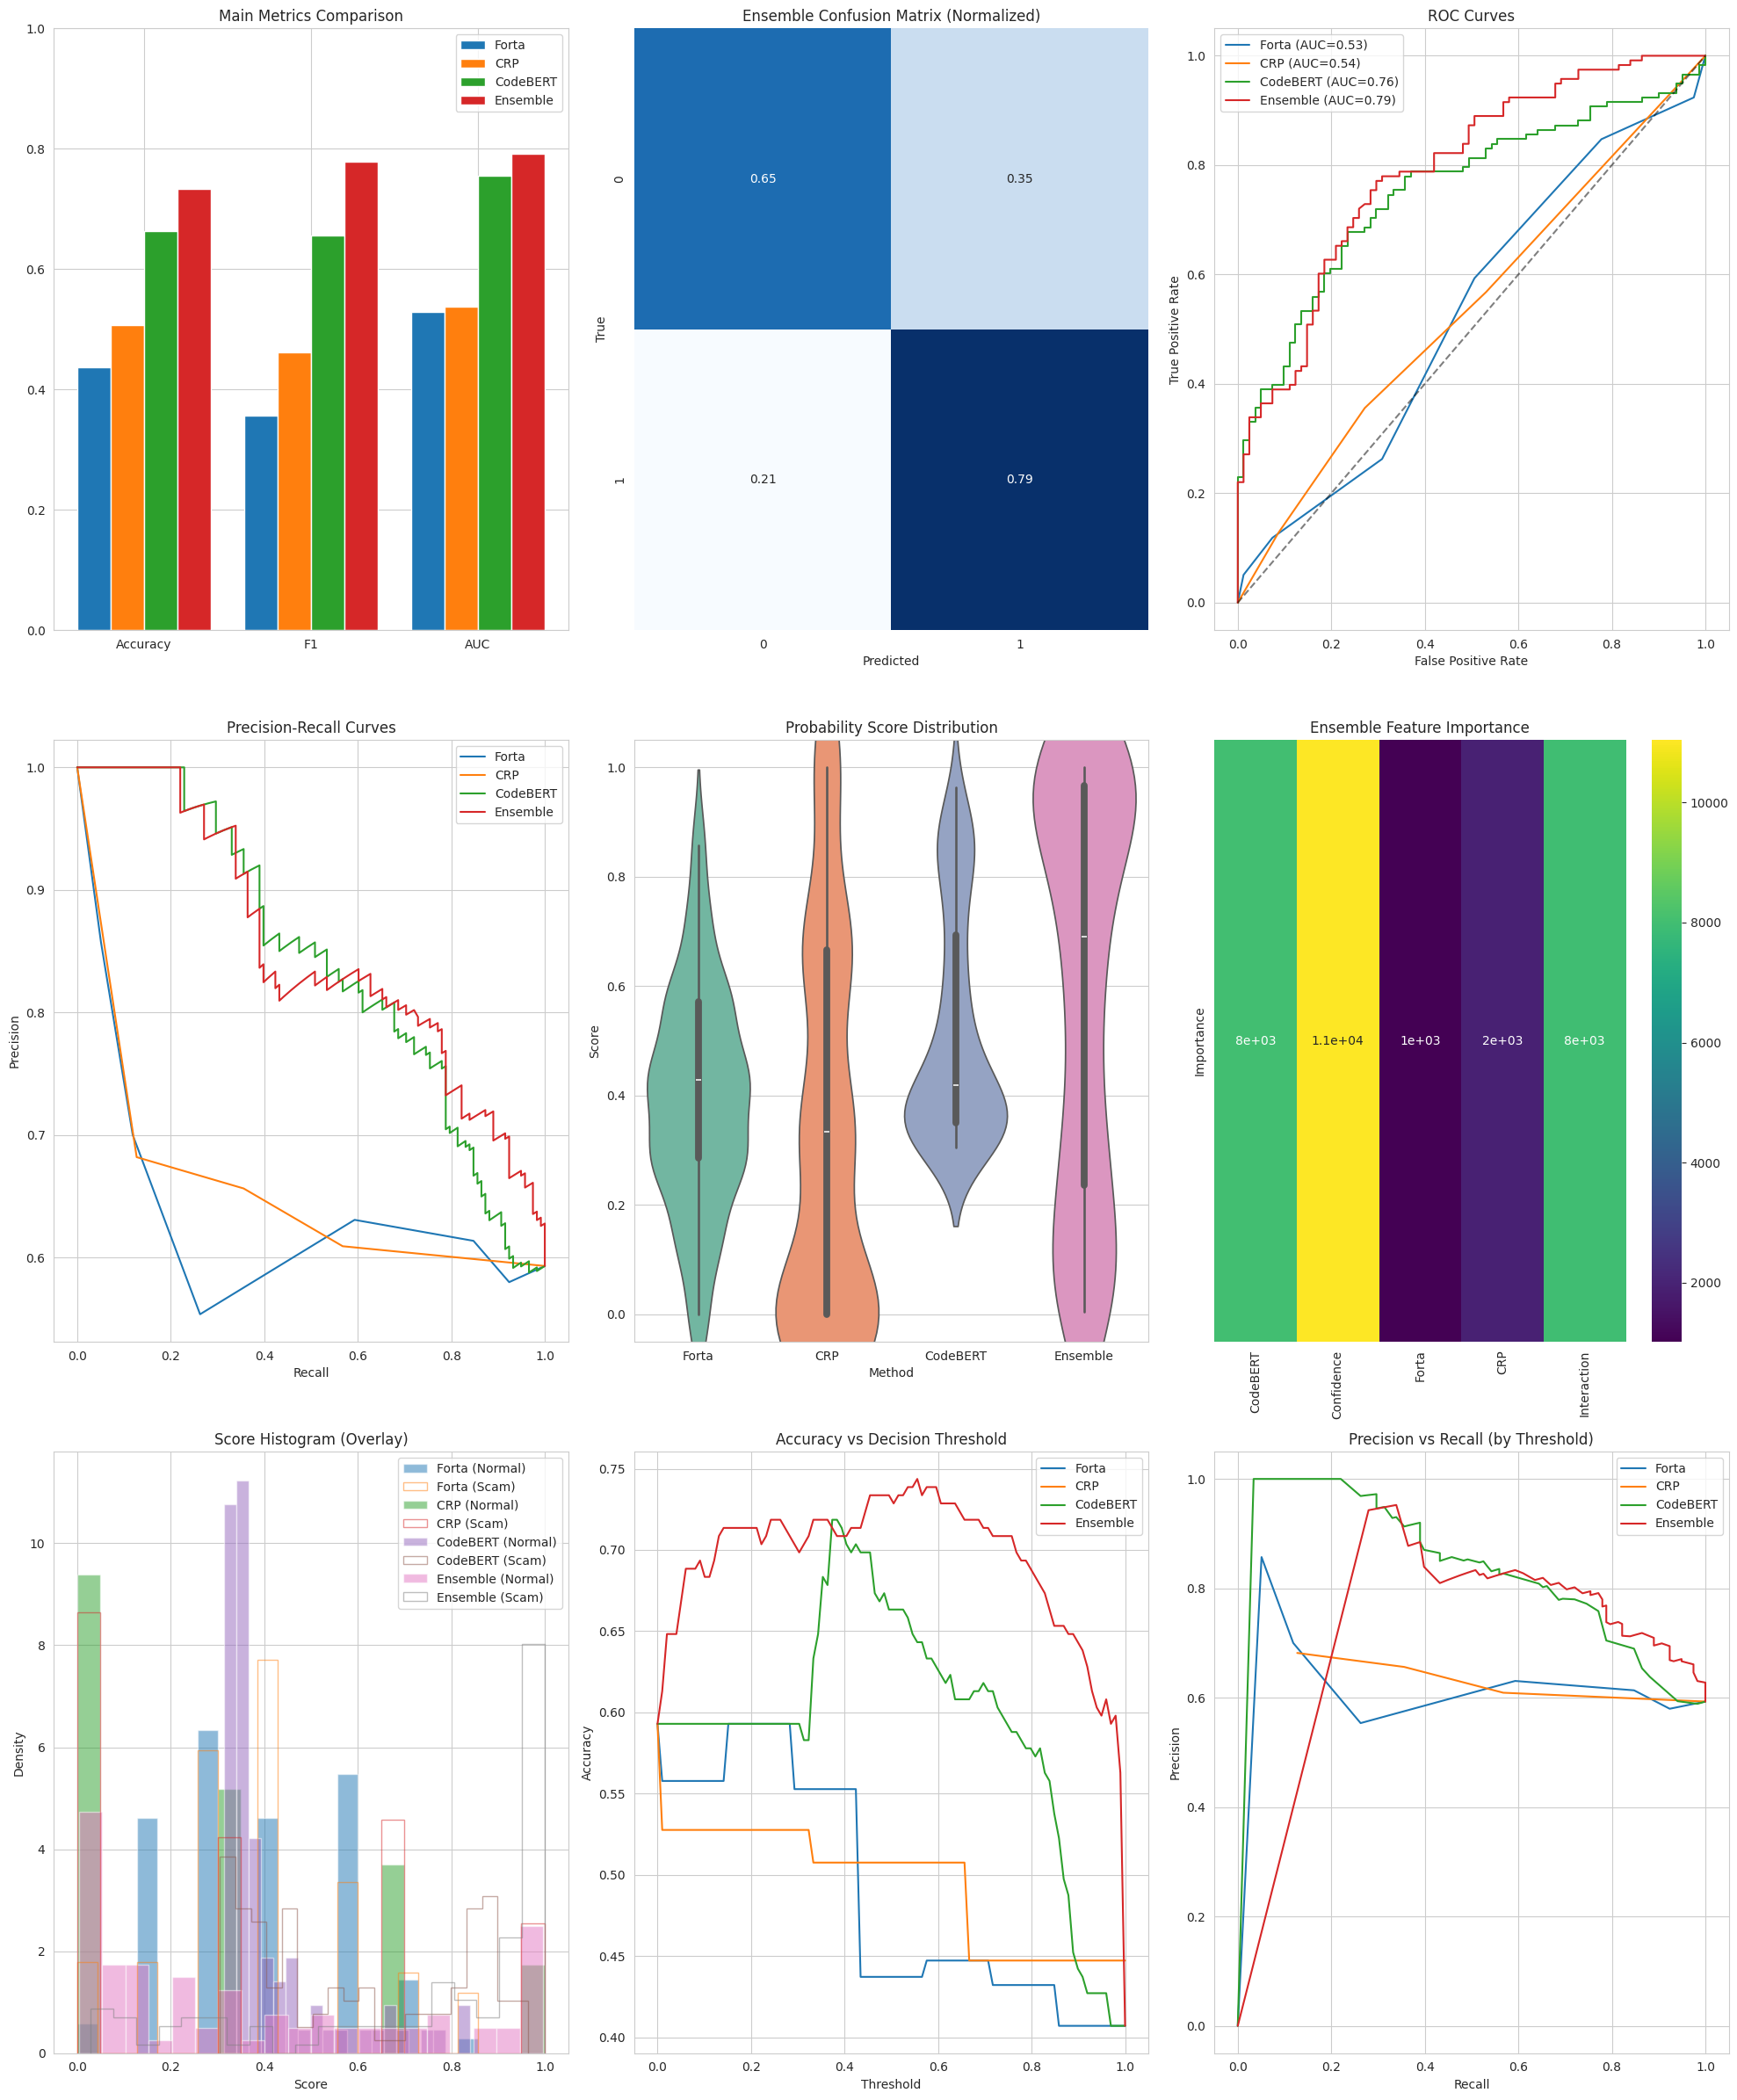


📊 نتایج نهایی (روی تست‌ست یکسان)

🔹 Forta:
  Accuracy: 0.4372
  Precision: 0.5536
  Recall: 0.2627
  F1: 0.3563
  AUC: 0.5291

🔹 CRP:
  Accuracy: 0.5075
  Precision: 0.6562
  Recall: 0.3559
  F1: 0.4615
  AUC: 0.5377

🔹 CodeBERT:
  Accuracy: 0.6633
  Precision: 0.8312
  Recall: 0.5424
  F1: 0.6564
  AUC: 0.7553

🔹 Ensemble:
  Accuracy: 0.7337
  Precision: 0.7686
  Recall: 0.7881
  F1: 0.7782
  AUC: 0.7918

✅ نتایج در /content/model_comparison.csv ذخیره شد.
✅ نمودارها در /content/comprehensive_comparison.png ذخیره شد.


In [ ]:
# ========================
# ⚙️ نصب پیش‌نیازها
# ========================
!pip install -q transformers datasets accelerate openpyxl lightgbm matplotlib seaborn scikit-learn rarfile tqdm

# ========================
# 📦 آپلود فایل‌ها
# ========================
from google.colab import files
import os, pandas as pd, numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
)
import torch
import lightgbm as lgb
import rarfile
import matplotlib.pyplot as plt
import seaborn as sns

print("📂 آپلود dataset.xlsx"); dataset_file = list(files.upload().keys())[0]
print("📂 آپلود crpwarner.xlsx"); crp_file = list(files.upload().keys())[0]
print("📂 آپلود SOURCE CODE.rar"); rar_file = list(files.upload().keys())[0]

# ========================
# 📊 بارگذاری داده‌ها
# ========================
df = pd.read_excel(dataset_file)
df_crp = pd.read_excel(crp_file)

df["Smart Contract Offline"] = df["Smart Contract Offline"].astype(str)
df_crp["Smart Contract Offline"] = df_crp["Smart Contract Offline"].astype(str)
df["y"] = df["Label"].map({"normal": 0, "scam": 1}).astype(int)

df = df.merge(
    df_crp[["Smart Contract Offline", "HiddenMint", "LeakingToken", "LimitingSell"]],
    on="Smart Contract Offline", how="left"
)
df[["HiddenMint", "LeakingToken", "LimitingSell"]] = df[["HiddenMint", "LeakingToken", "LimitingSell"]].fillna(0)

y = df["y"].values
contract_ids = df["Smart Contract Offline"].values

# ========================
# 📂 استخراج کدها
# ========================
CODE_DIR = "/content/SOURCE_CODE"
os.makedirs(CODE_DIR, exist_ok=True)

!apt-get install -y unrar > /dev/null 2>&1
!unrar x -o+ "{rar_file}" "{CODE_DIR}" > /dev/null

paths = {}
for root, _, files in os.walk(CODE_DIR):
    for f in files:
        if f.endswith(".txt"):
            base = os.path.splitext(f)[0]
            paths[base] = os.path.join(root, f)

codes = [open(paths.get(cid, ""), "r", encoding="utf-8", errors="ignore").read() if cid in paths else ""
         for cid in contract_ids]

print(f"✅ تعداد کدهای بارگذاری‌شده: {sum(1 for c in codes if c)} / {len(codes)}")

# ========================
# 🔍 1. Forta
# ========================
def forta_prob(code):
    rules = ["mint(", "blacklist", "onlyowner", "withdraw",
             "transferownership", "delegatecall", "assembly"]
    return min(sum(r in code.lower() for r in rules) / len(rules), 1.0)

forta_scores = np.array([forta_prob(c) for c in codes])

# ========================
# 🔍 2. CRP
# ========================
crp_scores = df[["HiddenMint", "LeakingToken", "LimitingSell"]].sum(axis=1).values / 3

# ========================
# 🤖 3. CodeBERT خالص (برای تست‌ست)
# ========================
data = pd.DataFrame({"code": codes, "label": y})
data = data[data["code"] != ""].reset_index(drop=True)
train_df, test_df = train_test_split(data, test_size=0.2, stratify=data["label"], random_state=42)

train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)

MODEL_NAME = "microsoft/codebert-base"
MAX_LEN = 512

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

def tokenize_fn(examples):
    return tokenizer(
        examples["code"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

tokenized_train = train_dataset.map(tokenize_fn, batched=True)
tokenized_test = test_dataset.map(tokenize_fn, batched=True)
tokenized_train = tokenized_train.remove_columns(["code"]).rename_column("label", "labels")
tokenized_test = tokenized_test.remove_columns(["code"]).rename_column("label", "labels")

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    prec, rec, f1, _ = precision_recall_fscore_support(p.label_ids, preds, average="binary", zero_division=0)
    acc = accuracy_score(p.label_ids, preds)
    return {"accuracy": acc, "f1": f1, "precision": prec, "recall": rec}

training_args = TrainingArguments(
    output_dir="./codebert_tmp",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="no",
    load_best_model_at_end=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

trainer.train()

# احتمالات CodeBERT
cb_probs = trainer.predict(tokenized_test).predictions
cb_scores = torch.softmax(torch.tensor(cb_probs), dim=1).numpy()[:, 1]
cb_preds = np.argmax(cb_probs, axis=1)

# اندیس‌های تست
test_indices = test_df.index.tolist()
y_test = y[test_indices]
forta_test_scores = forta_scores[test_indices]
crp_test_scores = crp_scores[test_indices]

# ========================
# 🧠 4. Ensemble (OOF)
# ========================
print("🔄 در حال محاسبه Embedding CodeBERT برای تمام داده...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
bert = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device).eval()

def embed(c):
    if not c: return np.zeros(768)
    t = tok(c, truncation=True, max_length=512, padding="max_length", return_tensors="pt")
    t = {k: v.to(device) for k, v in t.items()}
    with torch.no_grad():
        o = bert.roberta(**t)  # فقط encoder
    return o.last_hidden_state.mean(1).cpu().numpy().flatten()

E = np.vstack([embed(c) for c in tqdm(codes)])

# OOF CodeBERT
oof_cb = np.zeros(len(y))
skf = StratifiedKFold(5, shuffle=True, random_state=42)
for tr, te in skf.split(E, y):
    cb = lgb.LGBMClassifier(n_estimators=800, learning_rate=0.05, num_leaves=64, random_state=42)
    cb.fit(E[tr], y[tr])
    oof_cb[te] = cb.predict_proba(E[te])[:, 1]

# Meta-Features
meta_X = np.column_stack([
    oof_cb,
    np.abs(oof_cb - 0.5),
    forta_scores,
    crp_scores,
    forta_scores * oof_cb
])

# Meta-Model
oof_ens = np.zeros(len(y))
meta_models = []
for tr, te in skf.split(meta_X, y):
    meta = lgb.LGBMClassifier(n_estimators=2000, learning_rate=0.02, num_leaves=16, min_data_in_leaf=30, random_state=42)
    meta.fit(meta_X[tr], y[tr])
    oof_ens[te] = meta.predict_proba(meta_X[te])[:, 1]
    meta_models.append(meta)

ens_test_scores = oof_ens[test_indices]
ens_preds = (ens_test_scores >= 0.5).astype(int)

# ========================
# 📊 جمع‌آوری امتیازات و پیش‌بینی‌ها
# ========================
methods = ["Forta", "CRP", "CodeBERT", "Ensemble"]
scores = [forta_test_scores, crp_test_scores, cb_scores, ens_test_scores]
preds = [(s >= 0.5).astype(int) for s in scores]

results = {}
for name, pred in zip(methods, preds):
    acc = accuracy_score(y_test, pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred, average="binary", zero_division=0)
    auc = roc_auc_score(y_test, scores[methods.index(name)])
    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "AUC": auc}

# ========================
# 📈 رسم 8 نمودار مقایسه‌ای
# ========================
sns.set_style("whitegrid")
fig = plt.figure(figsize=(20, 24))

# 1. معیارهای اصلی
ax1 = plt.subplot(3, 3, 1)
metrics = ["Accuracy", "F1", "AUC"]
x = np.arange(len(metrics))
width = 0.2
for i, method in enumerate(methods):
    vals = [results[method][m] for m in metrics]
    ax1.bar(x + i*width, vals, width, label=method)
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(metrics)
ax1.set_ylim(0, 1)
ax1.set_title("Main Metrics Comparison")
ax1.legend()

# 2. Confusion Matrix Ensemble
ax2 = plt.subplot(3, 3, 2)
cm = confusion_matrix(y_test, ens_preds, normalize='true')
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax2, cbar=False)
ax2.set_title("Ensemble Confusion Matrix (Normalized)")
ax2.set_xlabel("Predicted"); ax2.set_ylabel("True")

# 3. ROC Curves
ax3 = plt.subplot(3, 3, 3)
for name, score in zip(methods, scores):
    fpr, tpr, _ = roc_curve(y_test, score)
    auc = results[name]["AUC"]
    ax3.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
ax3.plot([0,1], [0,1], 'k--', alpha=0.5)
ax3.set_xlabel("False Positive Rate"); ax3.set_ylabel("True Positive Rate")
ax3.set_title("ROC Curves"); ax3.legend()

# 4. Precision-Recall Curves
ax4 = plt.subplot(3, 3, 4)
for name, score in zip(methods, scores):
    prec, rec, _ = precision_recall_curve(y_test, score)
    ax4.plot(rec, prec, label=name)
ax4.set_xlabel("Recall"); ax4.set_ylabel("Precision")
ax4.set_title("Precision-Recall Curves"); ax4.legend()

# 5. Probability Density (Violin)
ax5 = plt.subplot(3, 3, 5)
prob_df = pd.DataFrame({
    "Score": np.concatenate(scores),
    "Method": np.concatenate([[m]*len(s) for m, s in zip(methods, scores)])
})
sns.violinplot(data=prob_df, x="Method", y="Score", ax=ax5, palette="Set2")
ax5.set_title("Probability Score Distribution"); ax5.set_ylim(-0.05, 1.05)

# 6. Feature Importance Heatmap (فقط Ensemble)
ax6 = plt.subplot(3, 3, 6)
if meta_models:
    imp = np.mean([m.feature_importances_ for m in meta_models], axis=0)
    features = ["CodeBERT", "Confidence", "Forta", "CRP", "Interaction"]
    sns.heatmap([imp], annot=True, xticklabels=features, yticklabels=["Importance"], cmap="viridis", ax=ax6, cbar=True)
    ax6.set_title("Ensemble Feature Importance")

# 7. Score Histogram
ax7 = plt.subplot(3, 3, 7)
for name, score in zip(methods, scores):
    ax7.hist(score[y_test == 0], alpha=0.5, label=f"{name} (Normal)", bins=20, density=True)
    ax7.hist(score[y_test == 1], alpha=0.5, label=f"{name} (Scam)", bins=20, density=True, histtype='step')
ax7.set_xlabel("Score"); ax7.set_ylabel("Density")
ax7.set_title("Score Histogram (Overlay)"); ax7.legend()

# 8. Accuracy vs Threshold
ax8 = plt.subplot(3, 3, 8)
thresholds = np.linspace(0, 1, 100)
for name, score in zip(methods, scores):
    accs = [accuracy_score(y_test, score >= t) for t in thresholds]
    ax8.plot(thresholds, accs, label=name)
ax8.set_xlabel("Threshold"); ax8.set_ylabel("Accuracy")
ax8.set_title("Accuracy vs Decision Threshold"); ax8.legend()

# 9. Recall-Precision Tradeoff
ax9 = plt.subplot(3, 3, 9)
for name, score in zip(methods, scores):
    prs = []
    recs = []
    for t in thresholds:
        p = (score >= t).astype(int)
        prec = precision_recall_fscore_support(y_test, p, average="binary", zero_division=0)[0]
        rec = precision_recall_fscore_support(y_test, p, average="binary", zero_division=0)[1]
        prs.append(prec); recs.append(rec)
    ax9.plot(recs, prs, label=name)
ax9.set_xlabel("Recall"); ax9.set_ylabel("Precision")
ax9.set_title("Precision vs Recall (by Threshold)"); ax9.legend()

plt.tight_layout()
plt.savefig("/content/comprehensive_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# ========================
# 📋 گزارش نهایی
# ========================
print("\n" + "="*60)
print("📊 نتایج نهایی (روی تست‌ست یکسان)")
print("="*60)
for name, met in results.items():
    print(f"\n🔹 {name}:")
    for k, v in met.items():
        print(f"  {k}: {v:.4f}")

pd.DataFrame(results).T.to_csv("/content/model_comparison.csv")
print("\n✅ نتایج در /content/model_comparison.csv ذخیره شد.")
print("✅ نمودارها در /content/comprehensive_comparison.png ذخیره شد.")

In [ ]:
# ========================
# 📈 رسم 8+ نمودار و ذخیره در PDF
# ========================
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pdf_path = "/content/comprehensive_comparison_results.pdf"

with PdfPages(pdf_path) as pdf:

    # --- نمودار 1: معیارهای اصلی ---
    fig, ax = plt.subplots(figsize=(8, 6))
    metrics = ["Accuracy", "F1", "AUC"]
    x = np.arange(len(metrics))
    width = 0.2
    for i, method in enumerate(methods):
        vals = [results[method][m] for m in metrics]
        ax.bar(x + i*width, vals, width, label=method)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1)
    ax.set_title("Main Metrics Comparison")
    ax.legend()
    pdf.savefig(fig)
    plt.close(fig)

    # --- نمودار 2: Confusion Matrix Ensemble ---
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_test, ens_preds, normalize='true')
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax, cbar=False)
    ax.set_title("Ensemble Confusion Matrix (Normalized)")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    pdf.savefig(fig)
    plt.close(fig)

    # --- نمودار 3: ROC Curves ---
    fig, ax = plt.subplots(figsize=(7, 6))
    for name, score in zip(methods, scores):
        fpr, tpr, _ = roc_curve(y_test, score)
        auc = results[name]["AUC"]
        ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
    ax.plot([0,1], [0,1], 'k--', alpha=0.5)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves"); ax.legend()
    pdf.savefig(fig)
    plt.close(fig)

    # --- نمودار 4: Precision-Recall Curves ---
    fig, ax = plt.subplots(figsize=(7, 6))
    for name, score in zip(methods, scores):
        prec, rec, _ = precision_recall_curve(y_test, score)
        ax.plot(rec, prec, label=name)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curves"); ax.legend()
    pdf.savefig(fig)
    plt.close(fig)

    # --- نمودار 5: Probability Density (Violin) ---
    fig, ax = plt.subplots(figsize=(8, 6))
    prob_df = pd.DataFrame({
        "Score": np.concatenate(scores),
        "Method": np.concatenate([[m]*len(s) for m, s in zip(methods, scores)])
    })
    sns.violinplot(data=prob_df, x="Method", y="Score", ax=ax, palette="Set2")
    ax.set_title("Probability Score Distribution"); ax.set_ylim(-0.05, 1.05)
    pdf.savefig(fig)
    plt.close(fig)

    # --- نمودار 6: Feature Importance Heatmap ---
    if meta_models:
        fig, ax = plt.subplots(figsize=(8, 3))
        imp = np.mean([m.feature_importances_ for m in meta_models], axis=0)
        features = ["CodeBERT", "Confidence", "Forta", "CRP", "Interaction"]
        sns.heatmap([imp], annot=True, xticklabels=features, yticklabels=["Importance"], cmap="viridis", ax=ax)
        ax.set_title("Ensemble Feature Importance")
        pdf.savefig(fig)
        plt.close(fig)

    # --- نمودار 7: Score Histogram ---
    fig, ax = plt.subplots(figsize=(8, 6))
    for name, score in zip(methods, scores):
        ax.hist(score[y_test == 0], alpha=0.5, label=f"{name} (Normal)", bins=20, density=True)
        ax.hist(score[y_test == 1], alpha=0.5, label=f"{name} (Scam)", bins=20, density=True, histtype='step')
    ax.set_xlabel("Score"); ax.set_ylabel("Density")
    ax.set_title("Score Histogram (Overlay)"); ax.legend()
    pdf.savefig(fig)
    plt.close(fig)

    # --- نمودار 8: Accuracy vs Threshold ---
    fig, ax = plt.subplots(figsize=(7, 6))
    thresholds = np.linspace(0, 1, 100)
    for name, score in zip(methods, scores):
        accs = [accuracy_score(y_test, score >= t) for t in thresholds]
        ax.plot(thresholds, accs, label=name)
    ax.set_xlabel("Threshold"); ax.set_ylabel("Accuracy")
    ax.set_title("Accuracy vs Decision Threshold"); ax.legend()
    pdf.savefig(fig)
    plt.close(fig)

    # --- نمودار 9: Precision vs Recall (by Threshold) ---
    fig, ax = plt.subplots(figsize=(7, 6))
    for name, score in zip(methods, scores):
        prs, recs = [], []
        for t in thresholds:
            p = (score >= t).astype(int)
            prec = precision_recall_fscore_support(y_test, p, average="binary", zero_division=0)[0]
            rec = precision_recall_fscore_support(y_test, p, average="binary", zero_division=0)[1]
            prs.append(prec); recs.append(rec)
        ax.plot(recs, prs, label=name)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("Precision vs Recall (by Threshold)"); ax.legend()
    pdf.savefig(fig)
    plt.close(fig)

    # --- صفحه نتایج متنی (اختیاری) ---
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.axis('off')
    text = "Model Comparison Results (Test Set)\n\n"
    for name, met in results.items():
        text += f"{name}:\n"
        for k, v in met.items():
            text += f"  {k}: {v:.4f}\n"
        text += "\n"
    ax.text(0.1, 0.9, text, transform=ax.transAxes, fontsize=10, verticalalignment='top', family='monospace')
    ax.set_title("📊 Final Metrics Summary", fontsize=14)
    pdf.savefig(fig)
    plt.close(fig)

print(f"✅ تمام نمودارها در فایل ذخیره شدند: {pdf_path}")

# دانلود خودکار فایل PDF (اختیاری)
from google.colab import files
files.download(pdf_path)

/tmp/ipython-input-2656833245.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=prob_df, x="Method", y="Score", ax=ax, palette="Set2")


✅ تمام نمودارها در فایل ذخیره شدند: /content/comprehensive_comparison_results.pdf


/tmp/ipython-input-2656833245.py:128: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  pdf.savefig(fig)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>